# Car Prediction

In [23]:
import warnings, os
warnings.filterwarnings("ignore")

import pandas  as pd
import numpy   as np
import matplotlib
matplotlib.use("Agg")          # non-interactive backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
import joblib

OUTPUT = "/mnt/user-data/outputs"
os.makedirs(OUTPUT, exist_ok=True)

PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2",
           "#937860","#DA8BC3","#8C8C8C","#CCB974","#64B5CD"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 140, "axes.titlesize": 13,
                     "axes.labelsize": 11})


In [24]:
print("\n" + "="*60)
print("  STEP 1 : READING THE DATASET")
print("="*60)

df = pd.read_csv("CarPrice.csv")
print(f"  Rows : {df.shape[0]}   Columns : {df.shape[1]}")
print("\n  First 5 rows :")
print(df.head())



  STEP 1 : READING THE DATASET
  Rows : 205   Columns : 26

  First 5 rows :
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

  

In [25]:
print("\n" + "="*60)
print("  STEP 2 : EXPLORATORY DATA ANALYSIS")
print("="*60)


  STEP 2 : EXPLORATORY DATA ANALYSIS


In [26]:
print("\n  [INFO]")
df.info()


  [INFO]
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17

In [27]:
print("\n  [DESCRIBE — numerical columns]")
print(df.describe().T.to_string())


  [DESCRIBE — numerical columns]
                  count          mean          std      min      25%       50%       75%       max
car_ID            205.0    103.000000    59.322565     1.00    52.00    103.00    154.00    205.00
symboling         205.0      0.834146     1.245307    -2.00     0.00      1.00      2.00      3.00
wheelbase         205.0     98.756585     6.021776    86.60    94.50     97.00    102.40    120.90
carlength         205.0    174.049268    12.337289   141.10   166.30    173.20    183.10    208.10
carwidth          205.0     65.907805     2.145204    60.30    64.10     65.50     66.90     72.30
carheight         205.0     53.724878     2.443522    47.80    52.00     54.10     55.50     59.80
curbweight        205.0   2555.565854   520.680204  1488.00  2145.00   2414.00   2935.00   4066.00
enginesize        205.0    126.907317    41.642693    61.00    97.00    120.00    141.00    326.00
boreratio         205.0      3.329756     0.270844     2.54     3.15      3

In [28]:
print("\n  [NULL VALUE COUNT PER COLUMN]")
print(df.isnull().sum().to_string())



  [NULL VALUE COUNT PER COLUMN]
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0


In [29]:
print("\n  [DATA CLEANING]")
df.drop(columns=["car_ID"], inplace=True)
print("  ✔  Dropped 'car_ID' (index column, not a feature)")


  [DATA CLEANING]
  ✔  Dropped 'car_ID' (index column, not a feature)


In [30]:
df["CarBrand"] = df["CarName"].str.split().str[0].str.lower()
df.drop(columns=["CarName"], inplace=True)

In [16]:
print(df.columns)


Index(['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'price', 'CarBrand'],
      dtype='str')


In [31]:
brand_map = {"maxda": "mazda", "toyouta": "toyota",
             "vokswagen": "volkswagen", "vw": "volkswagen",
             "porcshce": "porsche"}
df["CarBrand"] = df["CarBrand"].replace(brand_map)
print(f"  ✔  Extracted 'CarBrand' from 'CarName'; corrected typos")

  ✔  Extracted 'CarBrand' from 'CarName'; corrected typos


In [32]:
empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    df.drop(columns=empty_cols, inplace=True)
    print(f"  ✔  Removed fully-empty columns: {empty_cols}")
else:
    print("  ✔  No fully-empty columns found")

  ✔  No fully-empty columns found


In [33]:
print("\n  [MISSING VALUE HANDLING]")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  ✔  '{col}' — filled with median")

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  ✔  '{col}' — filled with mode")

remaining_nulls = df.isnull().sum().sum()
print(f"  ✔  Total remaining nulls: {remaining_nulls}")


  [MISSING VALUE HANDLING]
  ✔  Total remaining nulls: 0


In [34]:
print("\n  [LABEL ENCODING — categorical → numerical]")
le = LabelEncoder()
cat_cols_updated = df.select_dtypes(include="object").columns.tolist()
encoding_map = {}

for col in cat_cols_updated:
    df[col] = le.fit_transform(df[col])
    unique_vals = list(le.classes_)
    encoding_map[col] = {cls: idx for idx, cls in enumerate(le.classes_)}
    print(f"  ✔  '{col}'  → {unique_vals}")

print(f"\n  Final DataFrame shape after cleaning: {df.shape}")


  [LABEL ENCODING — categorical → numerical]
  ✔  'fueltype'  → ['diesel', 'gas']
  ✔  'aspiration'  → ['std', 'turbo']
  ✔  'doornumber'  → ['four', 'two']
  ✔  'carbody'  → ['convertible', 'hardtop', 'hatchback', 'sedan', 'wagon']
  ✔  'drivewheel'  → ['4wd', 'fwd', 'rwd']
  ✔  'enginelocation'  → ['front', 'rear']
  ✔  'enginetype'  → ['dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
  ✔  'cylindernumber'  → ['eight', 'five', 'four', 'six', 'three', 'twelve', 'two']
  ✔  'fuelsystem'  → ['1bbl', '2bbl', '4bbl', 'idi', 'mfi', 'mpfi', 'spdi', 'spfi']
  ✔  'CarBrand'  → ['alfa-romero', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']

  Final DataFrame shape after cleaning: (205, 25)



  STEP 3 : DATA VISUALISATION


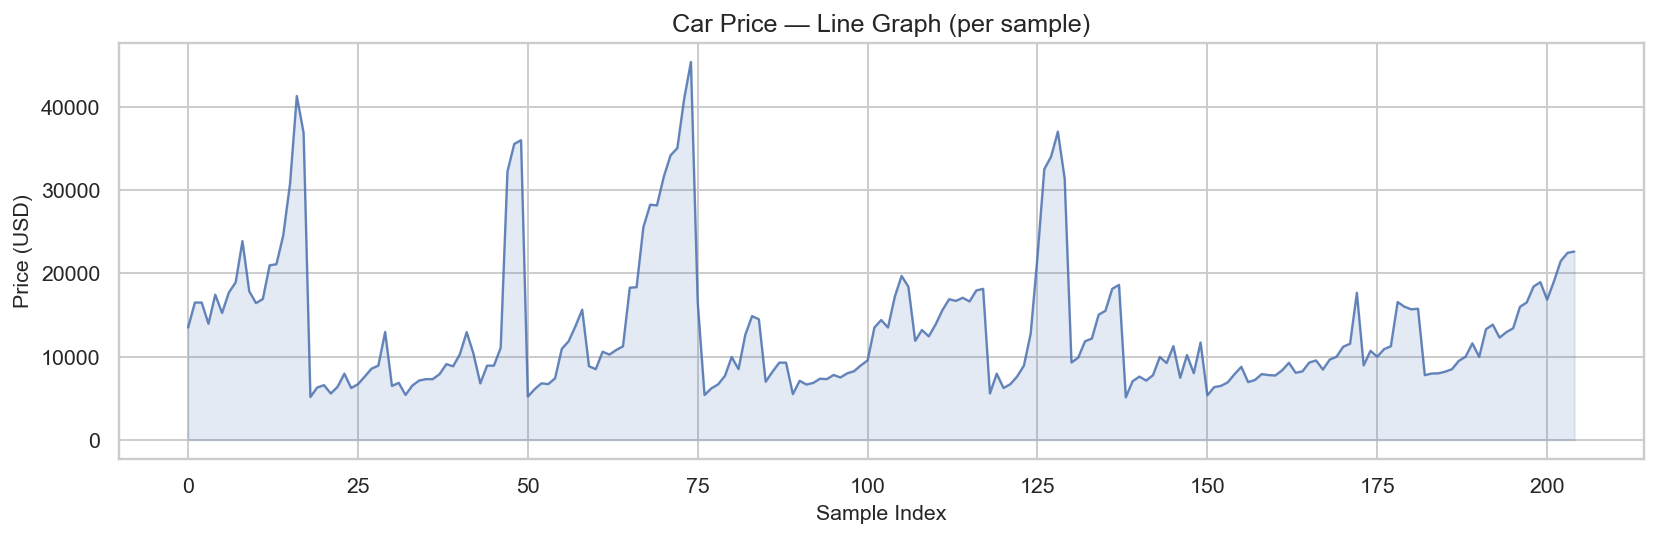

  ✔  Saved viz_01_line_price.png


In [73]:
print("\n" + "="*60)
print("  STEP 3 : DATA VISUALISATION")
print("="*60)

# ── Figure 1 : Line Graph — price trend per sample ──────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["price"], color=PALETTE[0], linewidth=1.2, alpha=0.85)
ax.fill_between(df.index, df["price"], alpha=0.15, color=PALETTE[0])
ax.set_title("Car Price — Line Graph (per sample)")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("viz_01_line_price.png")
plt.show()
plt.close()
print("  ✔  Saved viz_01_line_price.png")

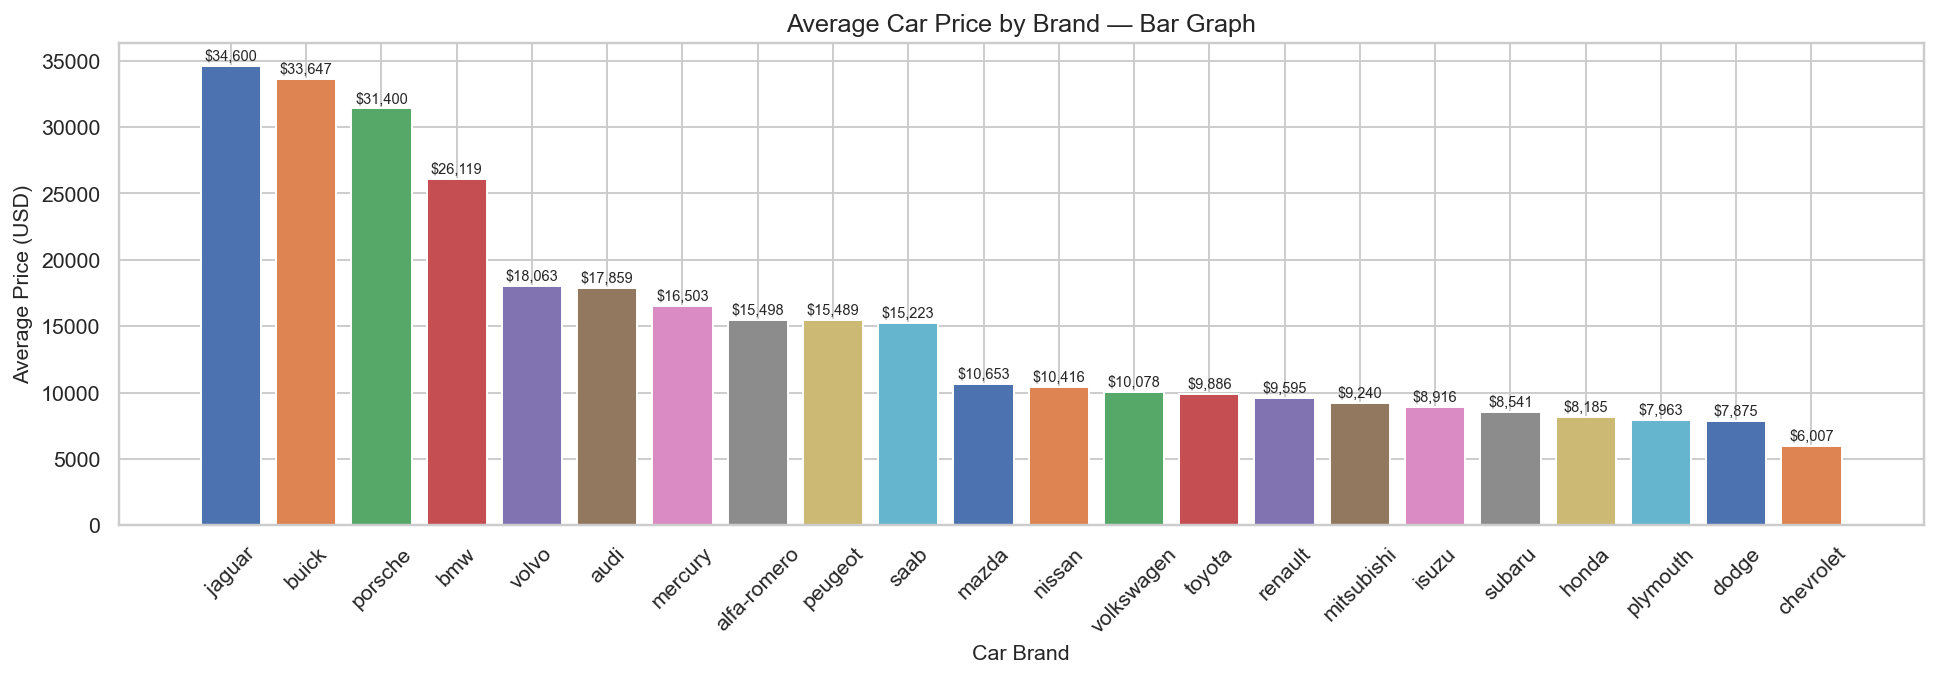

  ✔  Saved viz_02_bar_brand_price.png


In [74]:
brand_avg = df.groupby("CarBrand")["price"].mean().sort_values(ascending=False)
inv_brand = {v: k for k, v in encoding_map["CarBrand"].items()}
brand_avg.index = brand_avg.index.map(inv_brand)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(brand_avg.index, brand_avg.values,
              color=PALETTE[:len(brand_avg)] * (len(brand_avg)//len(PALETTE)+1))
ax.set_title("Average Car Price by Brand — Bar Graph")
ax.set_xlabel("Car Brand")
ax.set_ylabel("Average Price (USD)")
ax.tick_params(axis="x", rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f"${bar.get_height():,.0f}",
            ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.savefig("viz_02_bar_brand_price.png")
plt.show()
plt.close()
print("  ✔  Saved viz_02_bar_brand_price.png")


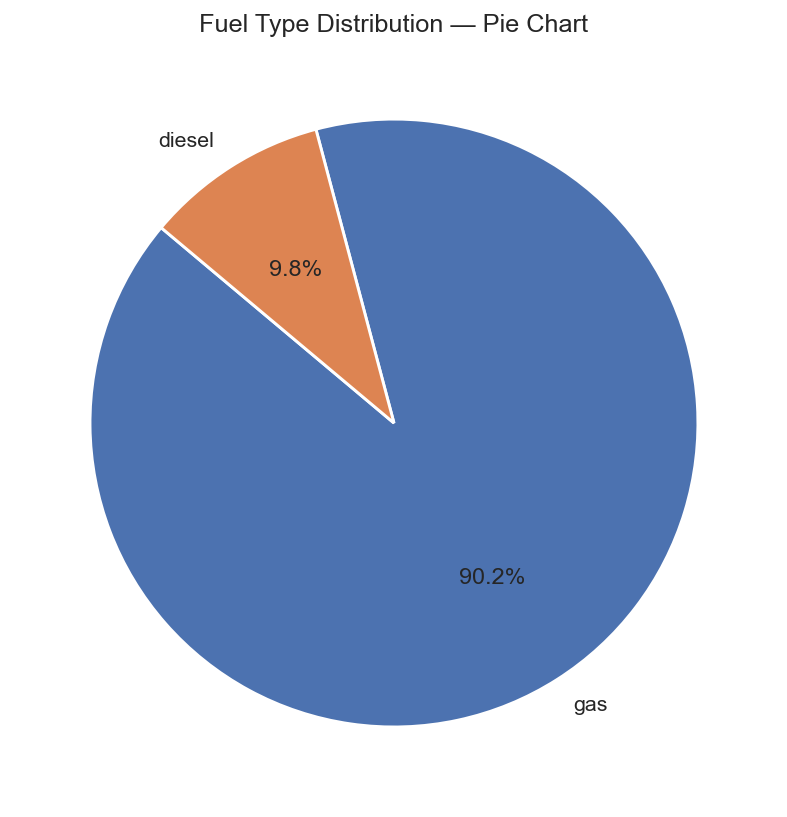

  ✔  Saved viz_03_pie_fueltype.png


In [75]:
inv_fuel = {v: k for k, v in encoding_map["fueltype"].items()}
fuel_counts = df["fueltype"].value_counts()
fuel_counts.index = fuel_counts.index.map(inv_fuel)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    fuel_counts.values,
    labels=fuel_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETTE[:len(fuel_counts)],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Fuel Type Distribution — Pie Chart")
plt.tight_layout()
plt.savefig("viz_03_pie_fueltype.png")
plt.show()
plt.close()
print("  ✔  Saved viz_03_pie_fueltype.png")

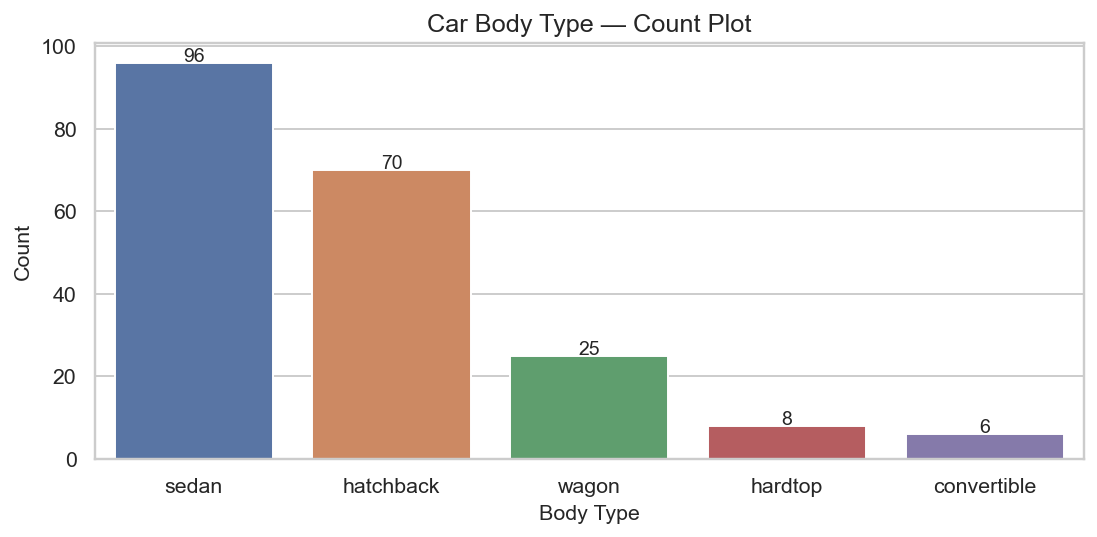

  ✔  Saved viz_04_count_carbody.png


In [76]:
inv_body = {v: k for k, v in encoding_map["carbody"].items()}
body_series = df["carbody"].map(inv_body)

fig, ax = plt.subplots(figsize=(8, 4))
order_vals = body_series.value_counts().index.tolist()
sns.countplot(x=body_series, order=order_vals, palette=PALETTE, ax=ax)
ax.set_title("Car Body Type — Count Plot")
ax.set_xlabel("Body Type")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+p.get_width()/2, p.get_height()+0.3),
                ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("viz_04_count_carbody.png")
plt.show()
plt.close()
print("  ✔  Saved viz_04_count_carbody.png")

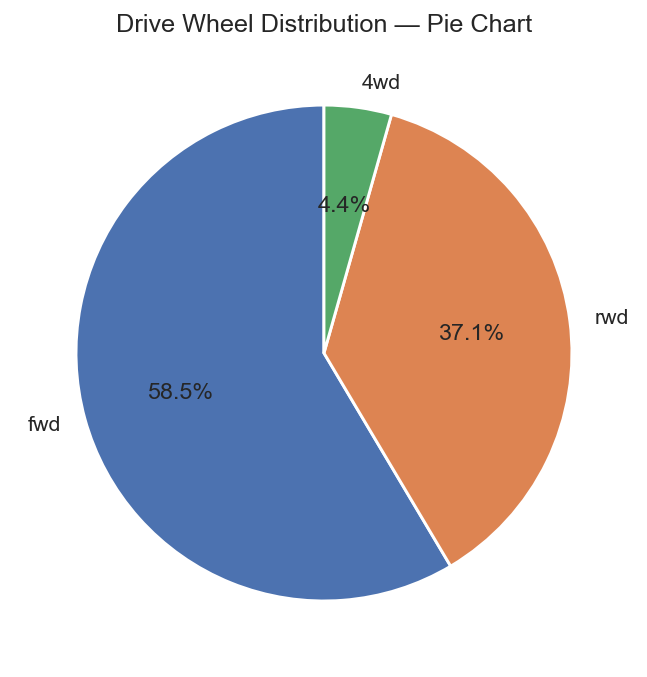

  ✔  Saved viz_05_pie_drivewheel.png


In [77]:
inv_drive = {v: k for k, v in encoding_map["drivewheel"].items()}
drive_counts = df["drivewheel"].value_counts()
drive_counts.index = drive_counts.index.map(inv_drive)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(drive_counts.values,
       labels=drive_counts.index,
       autopct="%1.1f%%",
       startangle=90,
       colors=PALETTE[:len(drive_counts)],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Drive Wheel Distribution — Pie Chart")
plt.tight_layout()
plt.savefig("viz_05_pie_drivewheel.png")
plt.show()
plt.close()
print("  ✔  Saved viz_05_pie_drivewheel.png")

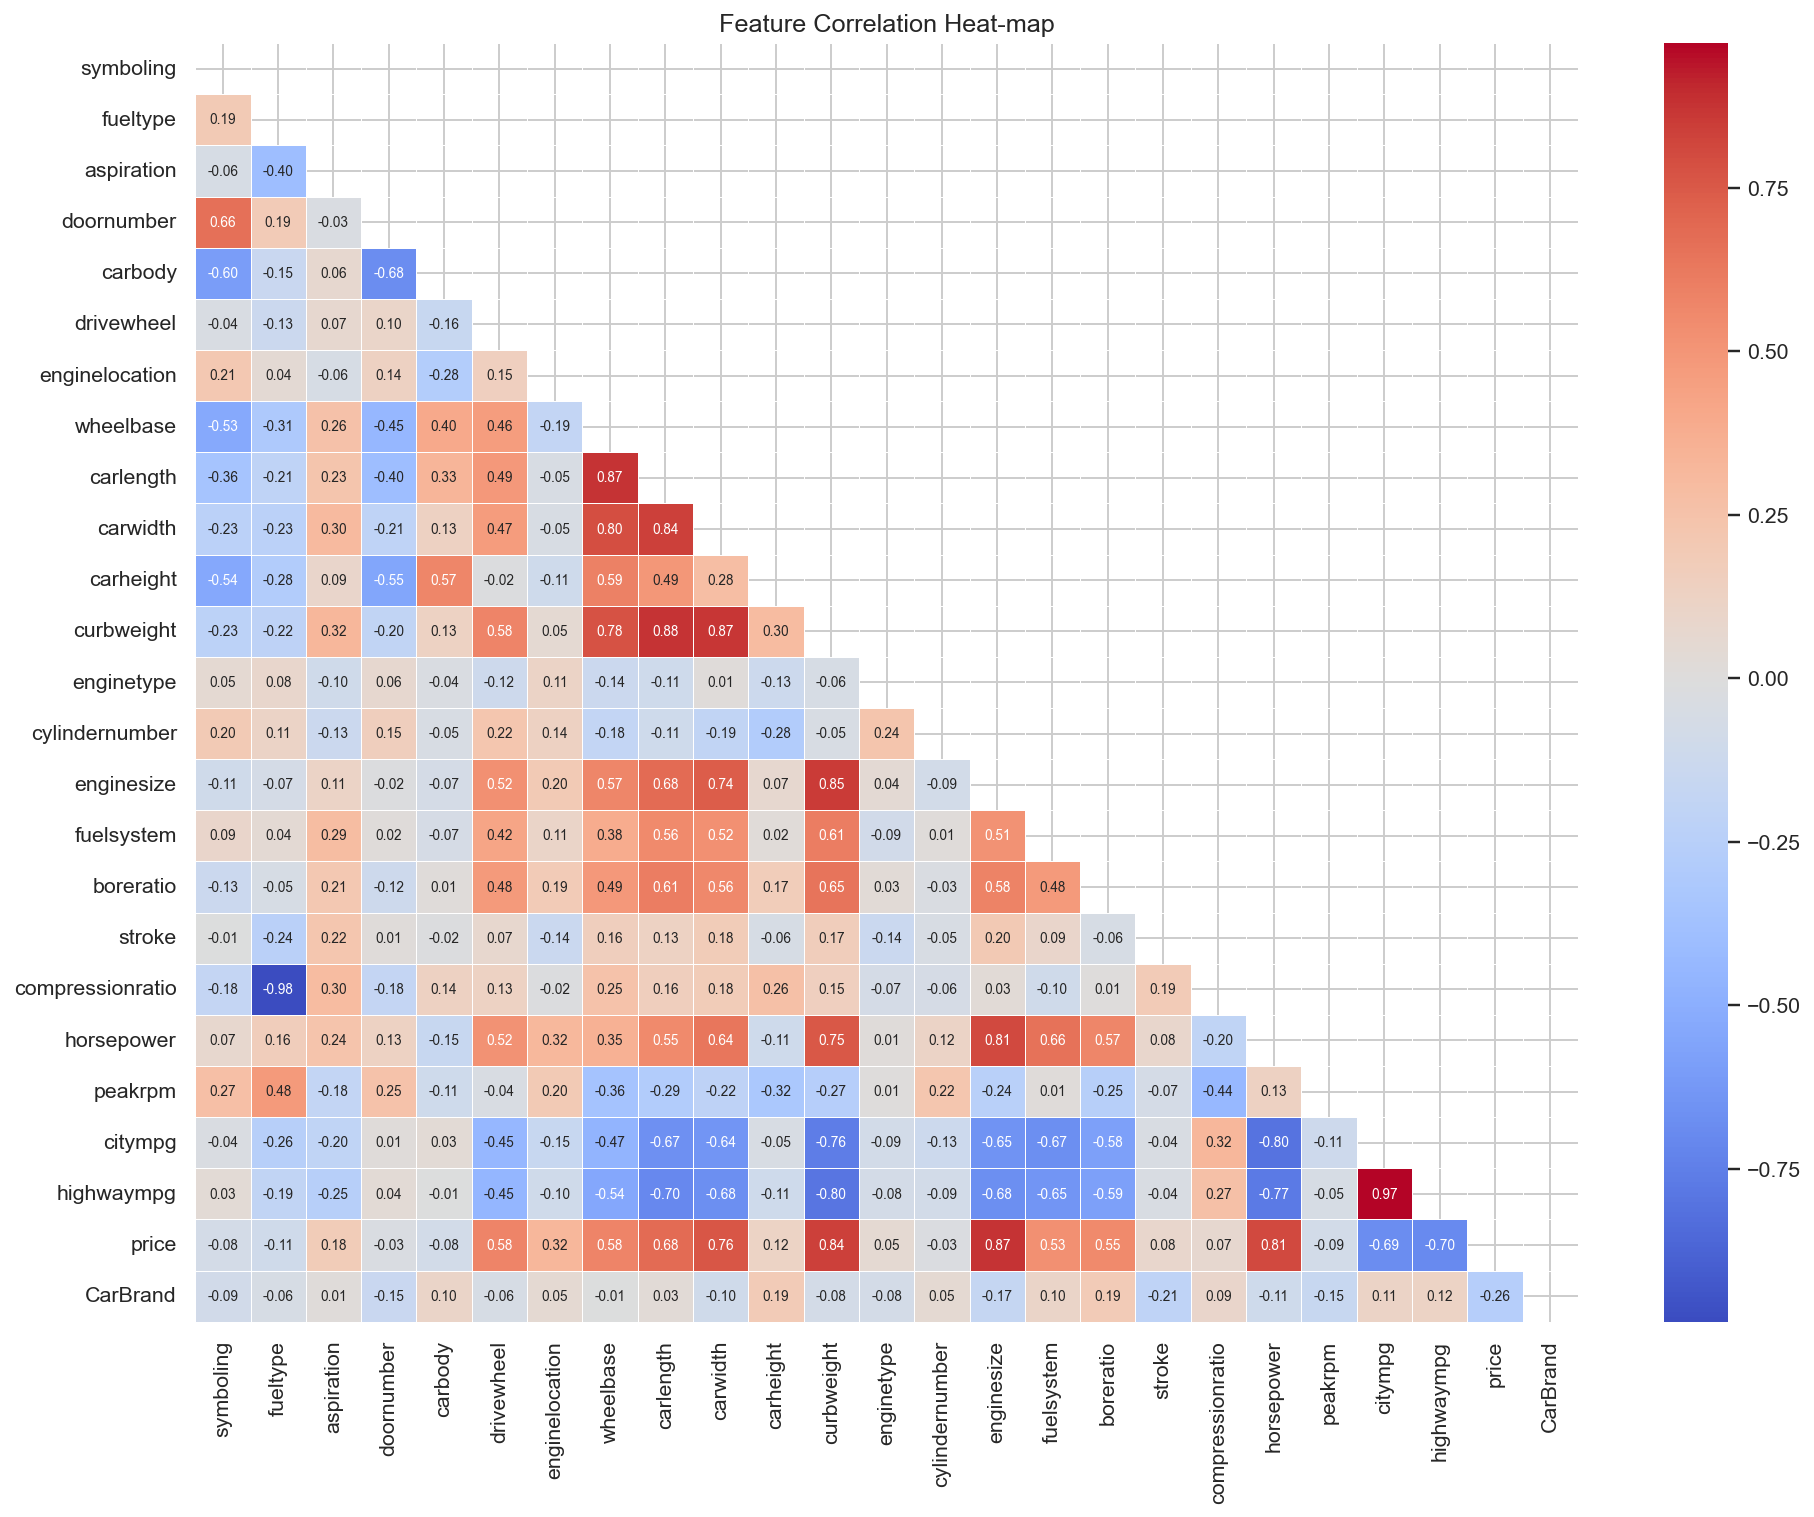

  ✔  Saved viz_06_heatmap.png


In [69]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature Correlation Heat-map")
plt.tight_layout()
plt.savefig("viz_06_heatmap.png")
plt.show()
plt.close()
print("  ✔  Saved viz_06_heatmap.png")

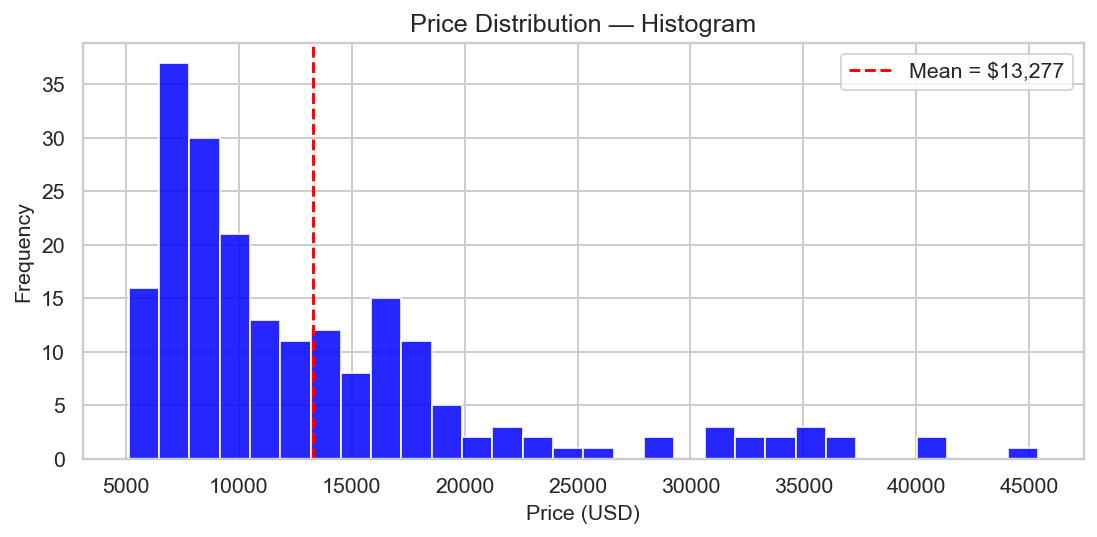

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df["price"], bins=30, color="blue", edgecolor="white", alpha=0.85)

ax.axvline(df["price"].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"Mean = ${df['price'].mean():,.0f}")

ax.set_title("Price Distribution — Histogram")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("viz_07_hist_price.png")
plt.show()
plt.close()

In [42]:
print("\n" + "="*60)
print("  STEP 4 : FEATURES, LABELS & TRAIN-TEST SPLIT")
print("="*60)

X = df.drop(columns=["price"])
y = df["price"]

print(f"  Features (X) shape : {X.shape}")
print(f"  Label   (y) shape  : {y.shape}")
print(f"  Feature columns    : {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"\n  Training set : {X_train.shape[0]} rows  ({80}%)")
print(f"  Test     set : {X_test.shape[0]}  rows  ({20}%)")



  STEP 4 : FEATURES, LABELS & TRAIN-TEST SPLIT
  Features (X) shape : (205, 24)
  Label   (y) shape  : (205,)
  Feature columns    : ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'CarBrand']

  Training set : 164 rows  (80%)
  Test     set : 41  rows  (20%)


In [43]:
print("\n" + "="*60)
print("  STEP 5 : TRAINING LINEAR REGRESSION MODEL")
print("="*60)

model = LinearRegression()
model.fit(X_train, y_train)
print("  ✔  Model trained successfully!")



  STEP 5 : TRAINING LINEAR REGRESSION MODEL
  ✔  Model trained successfully!


In [44]:
print("\n" + "="*60)
print("  STEP 6 : MODEL EVALUATION")
print("="*60)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)

print(f"\n  ┌─ Train ──────────────────────────────────┐")
print(f"  │  MSE   = {mse_train:>15,.2f}               │")
print(f"  │  R²    = {r2_train:>15.4f}               │")
print(f"  └──────────────────────────────────────────┘")
print(f"\n  ┌─ Test ───────────────────────────────────┐")
print(f"  │  MSE   = {mse_test:>15,.2f}               │")
print(f"  │  RMSE  = {rmse_test:>15,.2f}               │")
print(f"  │  MAE   = {mae_test:>15,.2f}               │")
print(f"  │  R²    = {r2_test:>15.4f}               │")
print(f"  └──────────────────────────────────────────┘")


  STEP 6 : MODEL EVALUATION

  ┌─ Train ──────────────────────────────────┐
  │  MSE   =    5,348,466.44               │
  │  R²    =          0.9103               │
  └──────────────────────────────────────────┘

  ┌─ Test ───────────────────────────────────┐
  │  MSE   =   12,163,932.55               │
  │  RMSE  =        3,487.68               │
  │  MAE   =        2,090.53               │
  │  R²    =          0.8459               │
  └──────────────────────────────────────────┘


In [45]:
print("\n" + "="*60)
print("  STEP 7 : MODEL VISUALISATION")
print("="*60)



  STEP 7 : MODEL VISUALISATION


In [46]:
coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\n  [REGRESSION COEFFICIENTS — sorted by magnitude]")
print(coef_df.to_string(index=False))
print(f"\n  Intercept : {model.intercept_:,.4f}")


  [REGRESSION COEFFICIENTS — sorted by magnitude]
         Feature  Coefficient
  enginelocation 11650.658080
        fueltype 11389.771060
          stroke -2015.801504
      doornumber -1340.566771
      aspiration  1130.591643
         carbody -1090.103327
compressionratio   958.190299
      drivewheel   695.731047
       boreratio  -621.029718
        carwidth   566.013645
      enginetype   260.776285
  cylindernumber  -218.138861
       carheight   193.532642
        CarBrand  -187.352009
       wheelbase   173.312796
         citympg  -150.529464
       symboling   141.401648
      fuelsystem   133.514099
      enginesize    78.118683
      highwaympg    77.273878
       carlength   -45.492456
      horsepower    19.476116
      curbweight     2.609878
         peakrpm     1.186736

  Intercept : -74,838.3641


In [47]:
print("\n  [REGRESSION EQUATION]")
eq_parts = []
for _, row in coef_df.head(5).iterrows():   # top 5 for readability
    sign = "+" if row["Coefficient"] >= 0 else "-"
    eq_parts.append(f"{sign} {abs(row['Coefficient']):.2f}×{row['Feature']}")
eq_str = f"price = {model.intercept_:.2f}  " + "  ".join(eq_parts) + "  + ..."
print(f"\n  {eq_str}\n")


  [REGRESSION EQUATION]

  price = -74838.36  + 11650.66×enginelocation  + 11389.77×fueltype  - 2015.80×stroke  - 1340.57×doornumber  + 1130.59×aspiration  + ...



In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_test,
                color=PALETTE[0], alpha=0.70, edgecolors="white", s=60)
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
axes[0].set_title("Actual vs Predicted — Test Set")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].legend()

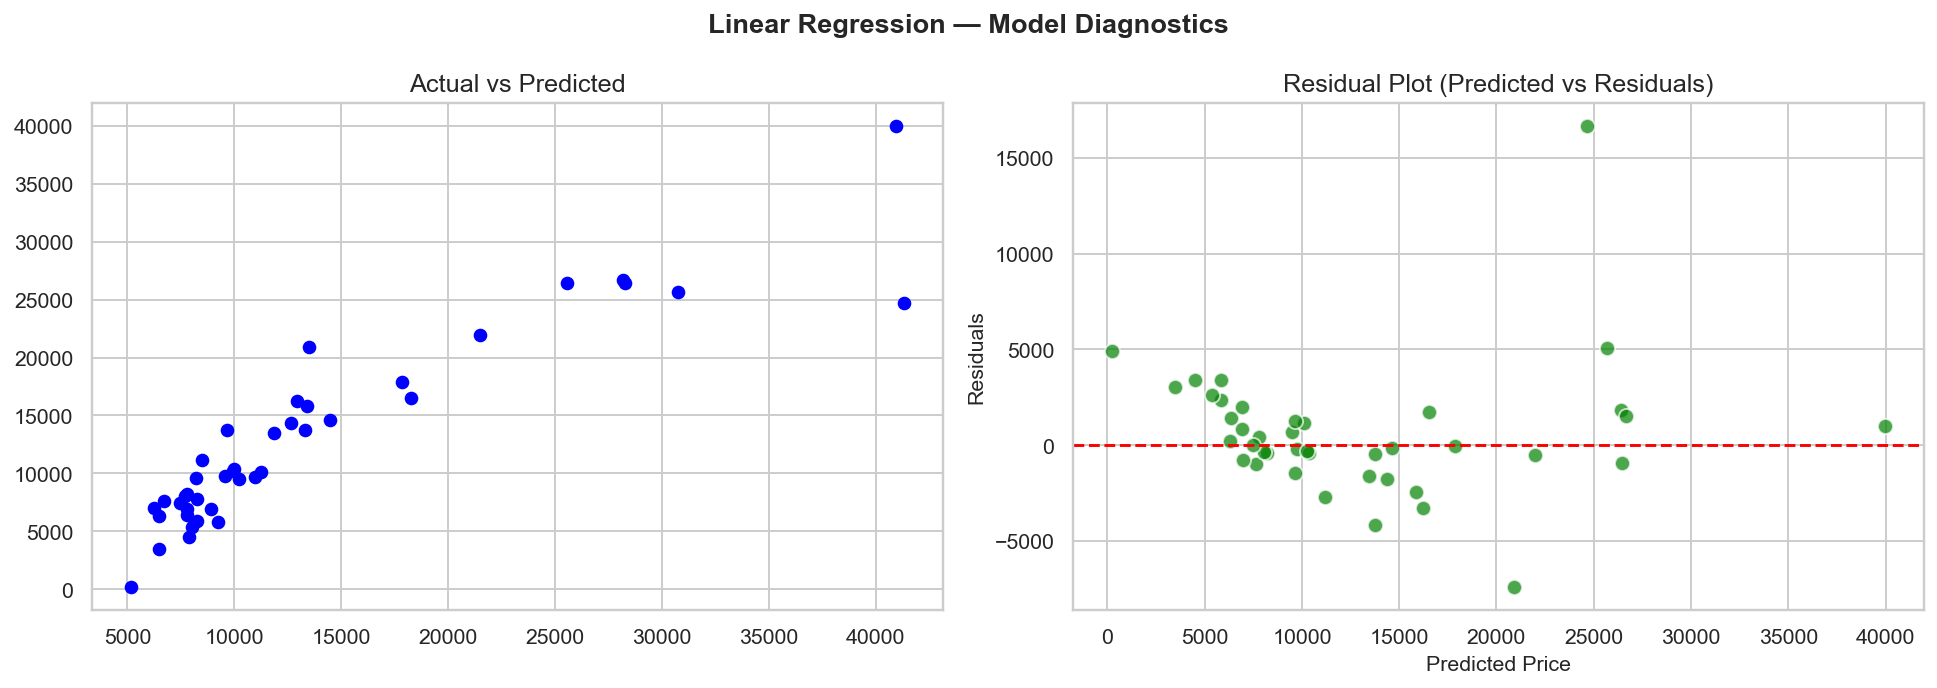

✔ Saved viz_08_model_diagnostics.png


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 👈 create axes

# Example: left plot (just to fill axes[0])
axes[0].scatter(y_test, y_pred_test, color="blue")
axes[0].set_title("Actual vs Predicted")

# Residual plot
residuals = y_test - y_pred_test

axes[1].scatter(y_pred_test, residuals,
                color="green", alpha=0.70, edgecolors="white", s=60)

axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residual Plot (Predicted vs Residuals)")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residuals")

plt.suptitle("Linear Regression — Model Diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("viz_08_model_diagnostics.png")
plt.show()
plt.close()

print("✔ Saved viz_08_model_diagnostics.png")

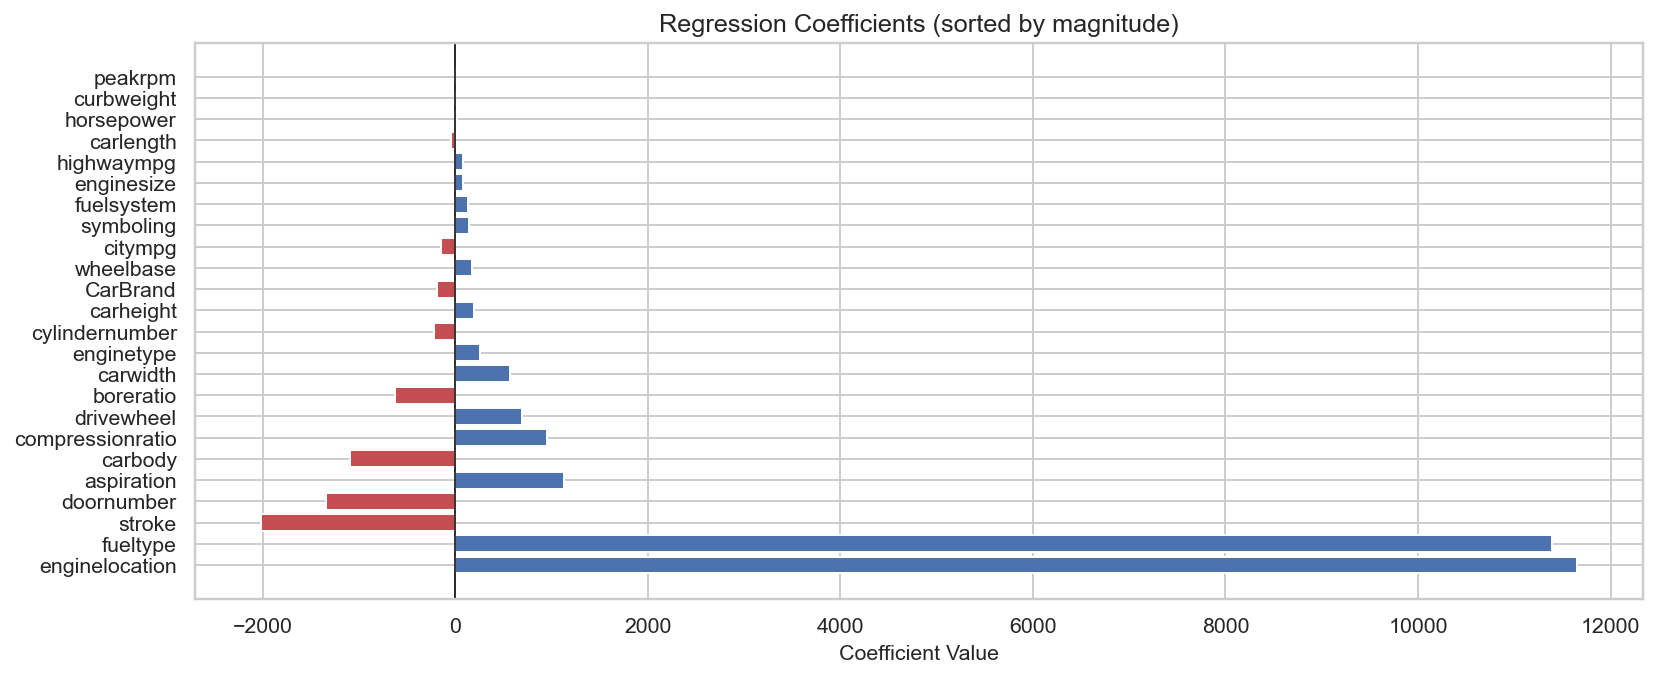

  ✔  Saved viz_09_coefficients.png


In [79]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[0] if c >= 0 else PALETTE[3] for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Regression Coefficients (sorted by magnitude)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("viz_09_coefficients.png")
plt.show()
plt.close()
print("  ✔  Saved viz_09_coefficients.png")

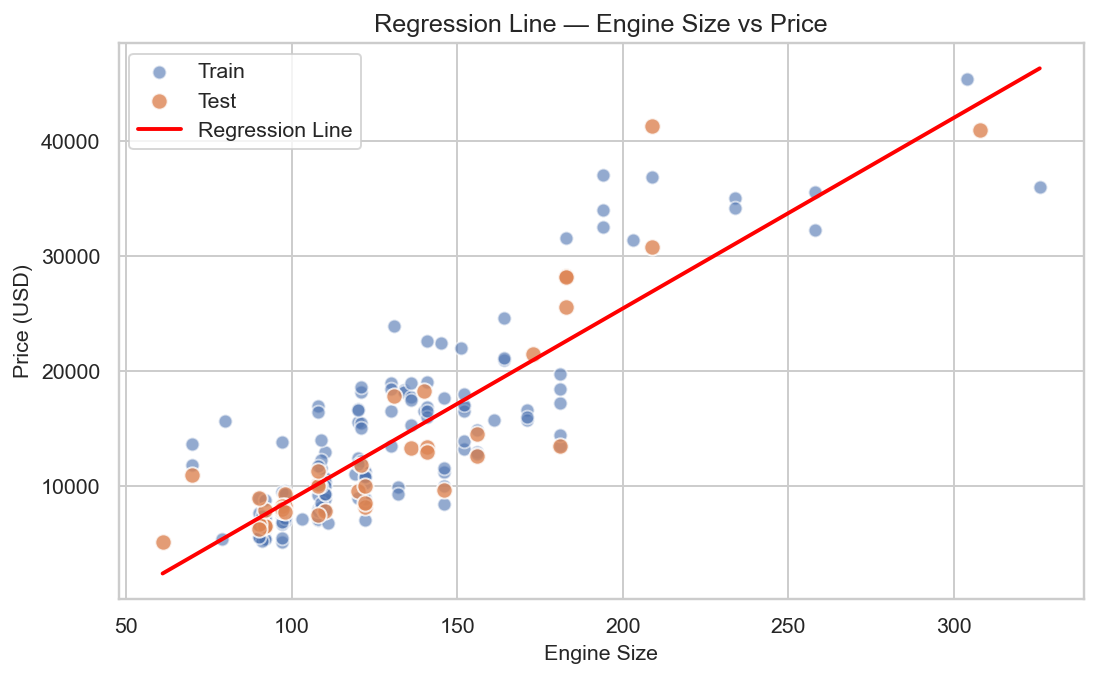

  ✔  Saved viz_10_regression_line.png


In [80]:
top_feat = "enginesize"
X_plot_tr = X_train[[top_feat]].values
X_plot_te = X_test[[top_feat]].values

from sklearn.linear_model import LinearRegression as LR1
lr1 = LR1().fit(X_plot_tr, y_train)
x_range = np.linspace(X[top_feat].min(), X[top_feat].max(), 200).reshape(-1, 1)
y_range = lr1.predict(x_range)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[top_feat], y_train,
           color=PALETTE[0], alpha=0.6, s=50, label="Train", edgecolors="white")
ax.scatter(X_test[top_feat],  y_test,
           color=PALETTE[1], alpha=0.8, s=70, label="Test",  edgecolors="white")
ax.plot(x_range, y_range, color="red", linewidth=2, label="Regression Line")
ax.set_title(f"Regression Line — Engine Size vs Price")
ax.set_xlabel("Engine Size")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("viz_10_regression_line.png")
plt.show()
plt.close()
print("  ✔  Saved viz_10_regression_line.png")


In [81]:
print("\n" + "="*60)
print("  STEP 8 : SAVE MODEL & REAL-TIME PREDICTION")
print("="*60)

MODEL_PATH = "car_price_model.pkl"
joblib.dump(model, MODEL_PATH)
print(f"  ✔  Model saved → {MODEL_PATH}")



  STEP 8 : SAVE MODEL & REAL-TIME PREDICTION
  ✔  Model saved → car_price_model.pkl


In [53]:
loaded_model = joblib.load(MODEL_PATH)

In [54]:
sample = pd.DataFrame([{
    "symboling":        0,
    "fueltype":         1,      
    "aspiration":       0,      
    "doornumber":       1,      
    "carbody":          3,      
    "drivewheel":       1,      
    "enginelocation":   0,      
    "wheelbase":       98.8,
    "carlength":      177.9,
    "carwidth":        64.1,
    "carheight":       52.4,
    "curbweight":    2337,
    "enginetype":       0,      
    "cylindernumber":   3,      
    "enginesize":     132,
    "fuelsystem":       1,      
    "boreratio":        3.47,
    "stroke":           2.68,
    "compressionratio": 9,
    "horsepower":      111,
    "peakrpm":        5000,
    "citympg":         21,
    "highwaympg":      27,
    "CarBrand":         0,      
}])

In [55]:
sample = sample[X.columns]
predicted_price = loaded_model.predict(sample)[0]

print(f"\n  Real-Time Prediction Demo")
print(f"  ──────────────────────────")
print(f"  Input  : mid-range sedan (enginesize=132, hp=111, fwd)")
print(f"  Output : Predicted Price = ${predicted_price:,.2f}")


  Real-Time Prediction Demo
  ──────────────────────────
  Input  : mid-range sedan (enginesize=132, hp=111, fwd)
  Output : Predicted Price = $12,066.29


In [56]:
conclusion = f"""
╔══════════════════════════════════════════════════════════════╗
║          CAR PRICE PREDICTION — CONCLUSION REPORT           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset          : 205 cars × 25 features (after cleaning) ║
║  Model            : Multiple Linear Regression               ║
║  Train / Test     : 80% / 20%  (164 / 41 samples)          ║
╠══════════════════════════════════════════════════════════════╣
║  EVALUATION METRICS                                          ║
║  ─────────────────────────────────────────────────────────  ║
║  Train R²         : {r2_train:.4f}                                ║
║  Test  R²         : {r2_test:.4f}                                ║
║  Test  MSE        : ${mse_test:>12,.2f}                       ║
║  Test  RMSE       : ${rmse_test:>12,.2f}                       ║
║  Test  MAE        : ${mae_test:>12,.2f}                       ║
╠══════════════════════════════════════════════════════════════╣
║  KEY INSIGHTS                                                ║
║  1. enginesize, curbweight, horsepower have the strongest   ║
║     positive correlation with price.                         ║
║  2. citympg & highwaympg are negatively correlated with     ║
║     price (performance cars guzzle fuel).                    ║
║  3. The model explains {r2_test*100:.1f}% of the variance in price.  ║
║  4. RMSE of ~${rmse_test:,.0f} is reasonable for the price range   ║
║     of $5,118 – $45,400.                                     ║
║  5. Real-time predictions work via the saved .pkl model.    ║
╚══════════════════════════════════════════════════════════════╝
"""

In [82]:
print(conclusion)

with open("conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion)

print("  ✔  Conclusion saved → conclusion.txt")
print("\n  ALL DONE!  Outputs saved ")


╔══════════════════════════════════════════════════════════════╗
║          CAR PRICE PREDICTION — CONCLUSION REPORT           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset          : 205 cars × 25 features (after cleaning) ║
║  Model            : Multiple Linear Regression               ║
║  Train / Test     : 80% / 20%  (164 / 41 samples)          ║
╠══════════════════════════════════════════════════════════════╣
║  EVALUATION METRICS                                          ║
║  ─────────────────────────────────────────────────────────  ║
║  Train R²         : 0.9103                                ║
║  Test  R²         : 0.8459                                ║
║  Test  MSE        : $12,163,932.55                       ║
║  Test  RMSE       : $    3,487.68                       ║
║  Test  MAE        : $    2,090.53                       ║
╠══════════════════════════════════════════════════════════════╣
║  KEY INSIGHTS                                  